# Fully Connected Neural Network: Forward Pass

In this task, we begin implementing a custom fully connected layer with a sigmoid activation function. In this notebook, you will need to implement the functionality for obtaining the output of a layer based on its input and build a fully connected neural network from several fully connected layers and activation functions.

We will use only Python and the numpy library.

In [1]:
# Environment and Apple Silicon availability check
import os
import platform

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
try:
    import torch
    if torch.backends.mps.is_available():
        torch_device = torch.device("mps")
    elif torch.cuda.is_available():
        torch_device = torch.device("cuda")
    else:
        torch_device = torch.device("cpu")
    print(f"PyTorch device available for tensor experiments: {torch_device}")
except Exception as exc:
    torch_device = "not available"
    print(f"PyTorch is not available in this environment: {exc}")

print(f"Platform: {platform.platform()}")
print("This notebook implements layers with NumPy arrays, so the model computations below run on CPU.")


PyTorch device available for tensor experiments: mps
Platform: macOS-26.4.1-arm64-arm-64bit-Mach-O
This notebook implements layers with NumPy arrays, so the model computations below run on CPU.


In [2]:
import numpy as np
np.random.seed(42)


## Abstract Class Module

All types of neural network layers that we will encounter in this course will be implemented in code as classes. First, let us define a general `Module` class, from which the classes of various layers and activation functions will inherit. The `Module` class will define four main methods that any layer or activation function must have:

In [3]:
class Module():
    '''
    Abstract parent class for all layer and activation function classes.
    '''

    def __init__(self):
        '''
        Method called when an instance of the class is created.
        This is where layer parameters will be defined.
        '''
        pass

    def forward(self, x):
        '''
        Method that implements the forward pass of the network. In other words,
        this method defines how the output is computed from the input data
        passed to the layer.

        params:
            x (np.ndarray) — input to the layer
        returns:
            out (np.ndarray) — output of the layer after all transformations
        '''
        return x

    def __call__(self, x):
        '''
        This method is invoked when an instance of the `Module` class is called.
        For example, in the following code:
            model = Module()
            model(x)
        When `model(x)` is called, the `__call__` method will be triggered.
        Here, we define that calling the `__call__` method will invoke the `forward`
        method, i.e., the line `model(x)` will be equivalent to `model.forward(x)`.
        You can read more about the `__call__` method in Python here:

        This method does not need to be overridden in child classes.
        '''
        return self.forward(x)

    def backward(self, x, grad_output):
        '''
        Method that implements the backward pass of the network.
        This method is used for training the layer. We will implement it later
        in the course after discussing how a neural network learns.
        '''
        return grad_output

### Task #1: Fully Connected Layer

Now, let's implement the class for a fully connected (linear) layer, inheriting from `Module`. Your task is to implement the `__init__` and `forward` methods.

At this stage, we will initialize the layer's weight matrices `W` and `b` using a normal distribution. We will discuss the initialization of neural network layer parameters in more detail in subsequent course modules.

In [4]:
class Linear(Module):
    '''
    A class implementing a fully connected layer of the network.
    '''

    def __init__(self, in_features, out_features, bias=True):
        '''
        Method that declares the weight matrices of the layer.

        params:
            in_features (int): number of input neurons in the layer
                               (first dimension of the layer weight matrix W)
            out_features (int): number of output neurons in the layer
                               (second dimension of the layer weight matrix W)
            bias (bool): whether the layer includes a bias vector, i.e.,
                         - if bias=True, the layer's output is computed as y = XW + b
                         - if bias=False, the layer's output is computed as y = XW
        '''

        # Define the weight matrix of the layer W. Initialize weights with random
        # values from a normal distribution (np.random.randn).
        self.W = np.random.randn(in_features, out_features)

        # Define the layer's bias vector b.

        # If bias=True, initialize vector b with random
        # values from a normal distribution (np.random.randn).
        if bias:
            self.b = np.random.randn(out_features)
        # If bias=False, initialize vector b with zeros.
        else:
            self.b = np.zeros(out_features)

    def forward(self, x):
        '''
        Method that implements the forward pass of the layer.

        params:
            x (np.array): a set of elements passed to the input of the network layer.
                          Has dimensions (n_elems, in_features), where:
                          - n_elems: number of elements in the set,
                          - in_features: dimensionality of each element in the set.
        returns:
            (np.array): the output of the network layer. Has dimensions (n_elems, out_features), where:
                          - n_elems: number of elements in the input set,
                          - out_features: dimensionality of each element in the set
                                           after passing through the layer.
        '''

        # Compute the layer's output:
        # output = XW + b
        return x @ self.W + self.b

**Answer: Linear layer.** The fully connected layer computes `X @ W + b`. For a batch with shape `(n_elems, in_features)` and weights with shape `(in_features, out_features)`, the output shape is `(n_elems, out_features)`.

The cells below check that the `Linear` class works correctly with different parameter values.

In [5]:

# Check 1
np.random.seed(42)

fc = Linear(100, 1)

# Input with 5 elements of size 100
dummy_input = np.random.randn(5, 100)
# When called here
fc_output = fc(dummy_input)

assert fc_output.shape == (5, 1), "Something is wrong. Make sure your layer produces a vector of the correct size."

true_output = np.array([[-2.80854792], [-6.15012063], [ 5.40455322], [ 0.78061916], [ 9.80006706]])
assert np.allclose(true_output, fc_output), "Something is wrong, your layer produces incorrect values."

In [6]:
# Check 2
np.random.seed(42)

fc = Linear(50, 5)

# Input with 10 elements of size 50
dummy_input = np.random.randn(2, 50)
fc_output = fc(dummy_input)

assert fc_output.shape == (2, 5), "Something is wrong. Make sure your layer produces a vector of the correct size."

fc_output
true_output = np.array([[ 8.93130885, -4.43669005,  9.40878967,  5.52158133, -1.34076761],
       [ 3.56378095,  1.22167558,  0.13870174,  1.6540047 , -7.03219369]])
assert np.allclose(true_output, fc_output), "Something is wrong, your layer produces incorrect values."

### Task 2: Sigmoid Activation Function

The activation function will also be implemented as a class inheriting from the `Module` class. This approach is convenient because it allows us to "assemble" a neural network from multiple modules (fully connected layers and activation functions) that have the same semantics. That is, both the fully connected layer and the activation function will call the `forward` method when an element \( X \) is passed to their input. In other words, we will treat the activation function as a network layer that has no trainable parameters.

We will later see why having the same semantics for layers and activation functions is useful when we implement the training functions for layers and neural networks.


Your task is to implement the `Sigmoid` class. For convenience, the formula for the sigmoid activation function is provided below:

$$
Sigmoid(x) = \frac{1}{1 + e^{-x}}
$$


In [7]:
class Sigmoid(Module):
    '''
    A class that implements the sigmoid activation function.

    This class does not need to override the `__init__` method,
    since the activation function has no trainable parameters to define.
    '''

    def _sigmoid(self, x):
        """
        A helper method that implements the sigmoid formula.

        params:
            x (np.ndarray): a set of elements.
                          Has dimensions (n_elems, in_features), where:
                          - n_elems: the number of elements in the set,
                          - in_features: the dimensionality of each element in the set.
        returns:
            (np.ndarray): a set of elements after applying the sigmoid function to each element.
                          Has dimensions (n_elems, in_features), where:
                          - n_elems: the number of elements in the input set,
                          - in_features: the dimensionality of each element in the set.
        """
        return 1. / (1 + np.exp(-x))


    def forward(self, x):
        """
        Method that implements the forward pass of the layer.

        params:
            x (np.ndarray): a set of elements.
                          Has dimensions (n_elems, in_features), where:
                          - n_elems: the number of elements in the set,
                          - in_features: the dimensionality of each element in the set.
        returns:
            (np.ndarray): a set of elements after applying the activation function.
                          Has dimensions (n_elems, in_features), where:
                          - n_elems: the number of elements in the input set,
                          - in_features: the dimensionality of each element in the set.
        """
        return self._sigmoid(x)


The cell below checks that the `Sigmoid` class works correctly with different parameter values.

**Answer: Sigmoid.** The sigmoid activation is `1 / (1 + exp(-x))`. It is applied elementwise and keeps the same tensor shape while mapping values into the `(0, 1)` interval.

In [8]:
import torch

sigma = Sigmoid()

dummy_input = np.random.randn(5, 100)
output = sigma(dummy_input)

assert np.allclose(torch.sigmoid(torch.Tensor(dummy_input)), output)


### Task #3: Fully Connected Neural Network

It’s time to assemble a real neural network from fully connected layers and the sigmoid activation function.

The neural network will also be implemented as a class inheriting from the `Module` class. Your task is to complete the neural network code.

Note: When implementing this task, it might not be entirely clear why we need two separate sigmoid activation function modules. It may seem like we could define one and call it after each layer. In fact, we’ll understand why this is necessary later, when we implement the training code for our network.

In [9]:
class NN(Module):
    '''
    A class for a fully connected neural network.
    '''

    def __init__(self):
        '''
        Method where the architecture of the neural network — its layers — is defined.
        '''
        self.fc1 = Linear(300, 200)
        self.sigmoid1 = Sigmoid()

        # Define two more layers:
        # 1. A fully connected layer of size (200, 1)
        self.fc2 = Linear(200, 1)
        # 2. A sigmoid activation function
        self.sigmoid2 = Sigmoid()

    def forward(self, x):
        '''
        Method that implements the forward pass of the network.

        params:
            x (np.ndarray): a set of elements passed to the input of the network.
                          Has dimensions (n_elems, in_features), where:
                          - n_elems: the number of elements in the set,
                          - in_features: the dimensionality of each element in the set.
        returns:
            (np.ndarray): the output of the network. Has dimensions (n_elems, out_features), where:
                          - n_elems: the number of elements in the input set,
                          - out_features: the dimensionality of each element in the set
                                           after passing through the network layers.
        '''
        # Pass the input through the first linear layer and sigmoid.
        x = self.fc1(x)
        x = self.sigmoid1(x)

        # Pass the result through the second linear layer and sigmoid.
        x = self.fc2(x)
        x = self.sigmoid2(x)

        return x


The cell below checks that the `NN` class works correctly with different parameter values.

In [10]:
np.random.seed(42)

model = NN()

dummy_input = np.random.randn(5, 300)
model_output = model(dummy_input)

true_output = np.array([[0.77771083], [0.99999991], [0.86983029], [0.99450219], [0.99999974]])
assert np.allclose(true_output, model_output), "Something is wrong, your layer produces incorrect values."


**Answer: Network architecture.** The network is `Linear(300, 200) -> Sigmoid -> Linear(200, 1) -> Sigmoid`. The final sigmoid returns one probability-like value per input row, which is appropriate for binary classification.

Congratulations! You’ve implemented the foundational classes for a fully connected layer, the sigmoid activation function, and assembled your first fully connected neural network using them.

Next, we’ll enhance the code created in this task: implement additional activation functions and write code to train the layers and the network.

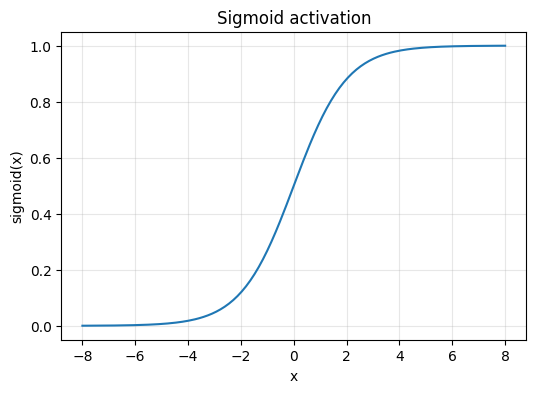

Linear smoke output shape: (4, 2)
Sigmoid output range: [0.0969, 0.9031]
Network smoke output shape: (4, 1)
Network output range: [0.0019, 0.9869]


In [11]:
# Small smoke experiment and visualization for the forward pass
import matplotlib.pyplot as plt

np.random.seed(7)
small_linear = Linear(3, 2)
small_input = np.random.randn(4, 3)
small_linear_output = small_linear(small_input)
small_sigmoid_output = Sigmoid()(small_linear_output)

small_model = NN()
small_model_output = small_model(np.random.randn(4, 300))

xs = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 4))
plt.plot(xs, Sigmoid()._sigmoid(xs))
plt.title("Sigmoid activation")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Linear smoke output shape: {small_linear_output.shape}")
print(f"Sigmoid output range: [{small_sigmoid_output.min():.4f}, {small_sigmoid_output.max():.4f}]")
print(f"Network smoke output shape: {small_model_output.shape}")
print(f"Network output range: [{small_model_output.min():.4f}, {small_model_output.max():.4f}]")


## Conclusions

- Apple Silicon availability was checked at the start of the notebook: PyTorch reported `mps` on `macOS-26.4.1-arm64-arm-64bit-Mach-O`. The implemented layers use NumPy arrays, so the forward-pass computations themselves run on CPU.
- The fully connected layer implements `X @ W + b`, and the provided checks passed for output shapes `(5, 1)` and `(2, 5)` with deterministic seeded values.
- The sigmoid implementation matched `torch.sigmoid` in the notebook check and maps values into `(0, 1)` without changing shape.
- The assembled network is `Linear(300, 200) -> Sigmoid -> Linear(200, 1) -> Sigmoid`; the provided deterministic test passed for a `(5, 300)` input and returned a `(5, 1)` output.
- The smoke experiment confirmed the smaller layer output shape `(4, 2)`, sigmoid output range `[0.0969, 0.9031]`, network output shape `(4, 1)`, and network output range `[0.0019, 0.9869]`.
- The sigmoid plot was added to visualize the activation curve: it saturates near `0` for large negative inputs and near `1` for large positive inputs, which explains why it is useful for probability-like binary outputs.
